# Árvore de Decisão - Predição de Evasão Universitária (OTIMIZADA)

**Objetivo**: Predição de alto risco de evasão usando Árvore de Decisão com melhorias de alto impacto

**Melhorias Implementadas**:
- ✅ Seleção de Features (SelectKBest com Mutual Information)
- ✅ Balanceamento de Classes (SMOTE)
- ✅ Hiperparâmetros Ampliados (200 iterações, 5-fold interno)
- ✅ Pós-Poda (Cost Complexity Pruning)
- ✅ Threshold Tuning

**Configurações**:
- Sample: 30.000 registros (estratificado)
- Cross-validation: 5-fold estratificado  
- Otimização: RandomizedSearchCV (200 iterações, 5-fold interno)
- Métricas: Accuracy, F1, Precision, Recall
- Tempo estimado: 30-45 minutos

In [23]:
# ============================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS (VERSÃO OTIMIZADA)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from scipy.stats import randint, uniform

# MELHORIAS: Importar SMOTE para balanceamento
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("✅ SMOTE disponível para balanceamento")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️  SMOTE não disponível. Instale com: pip install imbalanced-learn")

np.random.seed(42)
print("✅ Bibliotecas importadas com sucesso!")

✅ SMOTE disponível para balanceamento
✅ Bibliotecas importadas com sucesso!


In [24]:
# ============================================================================
# CÉLULA 2: FUNÇÕES AUXILIARES (COM MELHORIAS)
# ============================================================================

def safe_div(a, b, fill=0.0):
    """Divisão segura para evitar divisão por zero."""
    a = pd.to_numeric(a, errors='coerce').fillna(0)
    b = pd.to_numeric(b, errors='coerce').fillna(0)
    return np.where(b > 0, a / b, fill)

def handle_missing_mode(X, y):
    """Substitui valores ausentes pela moda de cada coluna."""
    X_filled = X.copy()
    for col in X_filled.columns:
        if X_filled[col].isnull().any():
            moda = X_filled[col].mode()
            fill_val = moda.iloc[0] if len(moda) > 0 else 0
            X_filled[col] = X_filled[col].fillna(fill_val)
    return X_filled, y

def apply_label_encoding(X, cat_cols):
    """Aplica Label Encoding nas colunas categóricas."""
    X_enc = X.copy()
    for col in cat_cols:
        if col in X_enc.columns:
            le = LabelEncoder()
            vals = X_enc[col].fillna(-1).astype(str)
            X_enc[col] = le.fit_transform(vals)
    return X_enc

def encontrar_melhor_threshold(model, X_calib, y_calib):
    """Seleciona threshold por Youden J com guarda-corpo (auditoria)."""
    import sys
    from pathlib import Path
    root = Path.cwd()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    from analysis.audit.threshold import encontrar_melhor_threshold as _safe_thr
    y_proba = model.predict_proba(X_calib)[:, 1]
    sel = _safe_thr(np.asarray(y_calib), y_proba)
    return sel.threshold, sel.calibration_f1


print("✅ Funções auxiliares definidas (incluindo threshold tuning).")

✅ Funções auxiliares definidas (incluindo threshold tuning).


In [25]:
# ============================================================================
# CÉLULA 3: CARREGAMENTO DOS DADOS
# ============================================================================

print("\n" + "=" * 70)
print(" CARREGAMENTO DOS DADOS")
print("=" * 70)

COLS_CURSOS = [
    'QT_ING', 'QT_MAT', 'QT_CONC', 'QT_SIT_DESVINCULADO', 'QT_SIT_TRANCADA',
    'QT_VG_TOTAL', 'QT_VG_TOTAL_EAD', 'QT_VG_TOTAL_NOTURNO',
    'QT_ING_FEM', 'QT_ING_18_24', 'QT_INSCRITO_TOTAL',
    'QT_MAT_FINANC', 'QT_ING_FIES', 'QT_ING_PROUNIP',
    'TP_ORGANIZACAO_ACADEMICA', 'TP_REDE', 'TP_CATEGORIA_ADMINISTRATIVA',
    'TP_GRAU_ACADEMICO', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO',
    'IN_GRATUITO', 'CO_CINE_AREA_GERAL',
]

print("Carregando dados...")
cursos_df = pd.read_csv(
    './MICRODADOS_CADASTRO_CURSOS_2024.CSV',
    sep=';', encoding='latin1', low_memory=False,
    usecols=COLS_CURSOS
)
print(f"✅ Cursos carregados: {cursos_df.shape[0]:,} linhas, {cursos_df.shape[1]} colunas")


 CARREGAMENTO DOS DADOS
Carregando dados...
✅ Cursos carregados: 720,349 linhas, 22 colunas


In [26]:
# ============================================================================
# CÉLULA 4: ENGENHARIA DE FEATURES
# ============================================================================

print("\n" + "=" * 70)
print(" ENGENHARIA DE FEATURES")
print("=" * 70)

# Conversão de colunas numéricas
count_cols = ['QT_ING','QT_MAT','QT_CONC','QT_SIT_DESVINCULADO','QT_SIT_TRANCADA',
              'QT_VG_TOTAL','QT_VG_TOTAL_EAD','QT_VG_TOTAL_NOTURNO',
              'QT_ING_FEM','QT_ING_18_24','QT_MAT_FINANC','QT_ING_FIES','QT_ING_PROUNIP']
for col in count_cols:
    cursos_df[col] = pd.to_numeric(cursos_df[col], errors='coerce').fillna(0)

# Criação de variáveis derivadas
cursos_df['QT_EVADIDOS'] = cursos_df['QT_SIT_DESVINCULADO'] + cursos_df['QT_SIT_TRANCADA']
cursos_df['TAXA_EVASAO'] = safe_div(cursos_df['QT_EVADIDOS'], cursos_df['QT_ING']) * 100
cursos_df['ALTO_RISCO_EVASAO'] = (cursos_df['TAXA_EVASAO'] >= 20).astype(int)

cursos_df['TAXA_CONCLUSAO'] = safe_div(cursos_df['QT_CONC'], cursos_df['QT_MAT']) * 100
cursos_df['RAZAO_ING_MAT'] = safe_div(cursos_df['QT_ING'], cursos_df['QT_MAT'])
cursos_df['PROPORCAO_EAD'] = safe_div(cursos_df['QT_VG_TOTAL_EAD'], cursos_df['QT_VG_TOTAL'])
cursos_df['PROPORCAO_NOTURNO'] = safe_div(cursos_df['QT_VG_TOTAL_NOTURNO'], cursos_df['QT_VG_TOTAL'])
cursos_df['INDICE_FINANCIAMENTO'] = safe_div(cursos_df['QT_MAT_FINANC'], cursos_df['QT_MAT'])
cursos_df['PROPORCAO_FIES'] = safe_div(cursos_df['QT_ING_FIES'], cursos_df['QT_ING'])
cursos_df['PROPORCAO_PROUNIP'] = safe_div(cursos_df['QT_ING_PROUNIP'], cursos_df['QT_ING'])
cursos_df['PROPORCAO_18_24'] = safe_div(cursos_df['QT_ING_18_24'], cursos_df['QT_ING'])
cursos_df['PROPORCAO_FEM'] = safe_div(cursos_df['QT_ING_FEM'], cursos_df['QT_ING'])

# 🔥 FEATURE ENGINEERING AVANÇADO (NOVAS FEATURES)
print("\n🔥 Criando features avançadas...")

# 1. Interações importantes
cursos_df['RAZAO_CONCLUSAO_EVASAO'] = safe_div(
    cursos_df['TAXA_CONCLUSAO'],
    cursos_df['TAXA_EVASAO'] + 1
)

# 2. Flags categóricos (features binárias)
cursos_df['EAD_PREDOMINANTE'] = (cursos_df['PROPORCAO_EAD'] > 0.5).astype(int)
cursos_df['FINANC_ALTO'] = (cursos_df['INDICE_FINANCIAMENTO'] > 0.7).astype(int)
cursos_df['CURSO_PEQUENO'] = (cursos_df['QT_ING'] < 50).astype(int)

# 3. Razões compostas
cursos_df['RAZAO_FEM_18_24'] = safe_div(
    cursos_df['PROPORCAO_FEM'],
    cursos_df['PROPORCAO_18_24'] + 0.1
)

# 4. Binning estratégico (discretização inteligente)
cursos_df['TAMANHO_CATEGORIA'] = pd.cut(
    cursos_df['QT_ING'],
    bins=[0, 30, 100, 300, np.inf],
    labels=[0, 1, 2, 3]  # Pequeno, Médio, Grande, Muito Grande
)
# Converter para int, tratando NaN como -1
cursos_df['TAMANHO_CATEGORIA'] = cursos_df['TAMANHO_CATEGORIA'].cat.codes
cursos_df['TAMANHO_CATEGORIA'] = cursos_df['TAMANHO_CATEGORIA'].fillna(-1).astype(int)

# 5. Interação financiamento x EAD
cursos_df['RAZAO_FINANC_EAD'] = safe_div(
    cursos_df['INDICE_FINANCIAMENTO'],
    cursos_df['PROPORCAO_EAD'] + 0.1
)

# 6. Taxa de preenchimento de vagas
cursos_df['TAXA_PREENCHIMENTO'] = safe_div(
    cursos_df['QT_ING'],
    cursos_df['QT_VG_TOTAL']
)

# 7. Razão inscritos/vagas (demanda do curso)
cursos_df['RAZAO_INSCRITOS_VAGAS'] = safe_div(
    cursos_df['QT_INSCRITO_TOTAL'],
    cursos_df['QT_VG_TOTAL']
)

# 8. Flag curso competitivo (alta demanda)
cursos_df['CURSO_COMPETITIVO'] = (
    cursos_df['RAZAO_INSCRITOS_VAGAS'] > 2
).astype(int)

print("✅ 10 novas features criadas!")

# Definição de features e target
CAT_FEATURES = [
    'TP_ORGANIZACAO_ACADEMICA', 'TP_REDE', 'TP_CATEGORIA_ADMINISTRATIVA',
    'TP_GRAU_ACADEMICO', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO',
    'IN_GRATUITO', 'CO_CINE_AREA_GERAL'
]
NUM_FEATURES_RAW = ['QT_ING','QT_MAT','QT_VG_TOTAL','QT_INSCRITO_TOTAL']
DERIVED_FEATURES = [
    'TAXA_CONCLUSAO','RAZAO_ING_MAT','PROPORCAO_EAD','PROPORCAO_NOTURNO',
    'INDICE_FINANCIAMENTO','PROPORCAO_FIES','PROPORCAO_PROUNIP',
    'PROPORCAO_18_24','PROPORCAO_FEM',
    # NOVAS FEATURES AVANÇADAS (10 features)
    'RAZAO_CONCLUSAO_EVASAO', 'EAD_PREDOMINANTE', 'FINANC_ALTO',
    'CURSO_PEQUENO', 'RAZAO_FEM_18_24', 'TAMANHO_CATEGORIA',
    'RAZAO_FINANC_EAD', 'TAXA_PREENCHIMENTO', 'RAZAO_INSCRITOS_VAGAS', 'CURSO_COMPETITIVO'
]
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES_RAW + DERIVED_FEATURES
TARGET = 'ALTO_RISCO_EVASAO'

print(f"\n✅ Features criadas: {len(ALL_FEATURES)} no total")
print(f"   - Categóricas: {len(CAT_FEATURES)}")
print(f"   - Numéricas brutas: {len(NUM_FEATURES_RAW)}")
print(f"   - Features derivadas: {len(DERIVED_FEATURES)} (incluindo 10 avançadas)")
print(f"\n📊 TOTAL: {len(ALL_FEATURES)} features para modelagem")


 ENGENHARIA DE FEATURES

🔥 Criando features avançadas...
✅ 10 novas features criadas!

✅ Features criadas: 31 no total
   - Categóricas: 8
   - Numéricas brutas: 4
   - Features derivadas: 19 (incluindo 10 avançadas)

📊 TOTAL: 31 features para modelagem


In [27]:
# ============================================================================
# CÉLULA 5: AMOSTRAGEM ESTRATIFICADA
# ============================================================================

print("\n" + "=" * 70)
print(" AMOSTRAGEM ESTRATIFICADA")
print("=" * 70)

# Filtrar cursos com ingressantes > 0
df_clean = cursos_df[cursos_df['QT_ING'] > 0].copy()
print(f"Cursos com QT_ING > 0: {df_clean.shape[0]:,}")

# Amostragem estratificada de 90.000 registros
SAMPLE_SIZE = 90000
classes_df = []
for cls in df_clean[TARGET].unique():
    cls_df = df_clean[df_clean[TARGET] == cls]
    n_sample = int(SAMPLE_SIZE * len(cls_df) / len(df_clean))
    n_sample = min(n_sample, len(cls_df))
    classes_df.append(cls_df.sample(n=n_sample, random_state=42))

dataset_sample = pd.concat(classes_df).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Amostra final: {dataset_sample.shape[0]:,} linhas")
print(f"\nDistribuição do target:")
print(dataset_sample[TARGET].value_counts())
print(f"\nProporção de alto risco: {dataset_sample[TARGET].mean():.2%}")

# Separação X e y
X_raw = dataset_sample[ALL_FEATURES].copy()
y_raw = dataset_sample[TARGET].copy()


 AMOSTRAGEM ESTRATIFICADA
Cursos com QT_ING > 0: 487,875

✅ Amostra final: 89,999 linhas

Distribuição do target:
ALTO_RISCO_EVASAO
1    67866
0    22133
Name: count, dtype: int64

Proporção de alto risco: 75.41%


In [28]:
# ============================================================================
# CÉLULA 6: PRÉ-PROCESSAMENTO COM SELEÇÃO DE FEATURES (MELHORIA 1)
# ============================================================================

print("\n" + "=" * 70)
print(" PRÉ-PROCESSAMENTO COM MELHORIAS")
print("=" * 70)

# Imputação de missings (moda)
X_mode, y_mode = handle_missing_mode(X_raw, y_raw)
print("✅ Missing values imputados (moda)")

# Label Encoding para categóricas
X_encoded = apply_label_encoding(X_mode, CAT_FEATURES)
print("✅ Label Encoding aplicado")

# Conversão para numpy arrays
X_temp = X_encoded.values.astype(np.float32)
y_processed = y_mode.values.astype(np.int32)

# MELHORIA 1: SELEÇÃO DE FEATURES COM MUTUAL INFORMATION
print("\n🔥 MELHORIA 1: Seleção de Features")
print("   Aplicando SelectKBest com Mutual Information...")

K_BEST = 21
selector = SelectKBest(mutual_info_classif, k=K_BEST)
X_processed = selector.fit_transform(X_temp, y_processed)

# Obter nomes das features selecionadas
feature_names = X_encoded.columns.tolist()
selected_indices = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]

# Obter scores de importância
feature_scores = selector.scores_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': feature_scores
}).sort_values('mi_score', ascending=False)

print(f"\n✅ Seleção de features concluída:")
print(f"   - Features originais: {X_temp.shape[1]}")
print(f"   - Features selecionadas: {K_BEST}")
print(f"\n📊 Top {K_BEST} features selecionadas:")
for i, feat in enumerate(selected_feature_names, 1):
    score = feature_importance_df[feature_importance_df['feature'] == feat]['mi_score'].values[0]
    print(f"   {i:2d}. {feat:30s} (MI: {score:.4f})")

print(f"\n✅ Dados processados finais:")
print(f"   - Shape: {X_processed.shape}")
print(f"   - Features: {X_processed.shape[1]}")
print(f"   - Amostras: {X_processed.shape[0]}")

# Salvar nomes das features para uso posterior
feature_names_final = selected_feature_names


 PRÉ-PROCESSAMENTO COM MELHORIAS
✅ Missing values imputados (moda)
✅ Label Encoding aplicado

🔥 MELHORIA 1: Seleção de Features
   Aplicando SelectKBest com Mutual Information...

✅ Seleção de features concluída:
   - Features originais: 31
   - Features selecionadas: 21

📊 Top 21 features selecionadas:
    1. TP_ORGANIZACAO_ACADEMICA       (MI: 0.0079)
    2. TP_REDE                        (MI: 0.0129)
    3. TP_CATEGORIA_ADMINISTRATIVA    (MI: 0.0110)
    4. TP_MODALIDADE_ENSINO           (MI: 0.0217)
    5. TP_DIMENSAO                    (MI: 0.0217)
    6. QT_ING                         (MI: 0.0738)
    7. QT_MAT                         (MI: 0.1134)
    8. QT_VG_TOTAL                    (MI: 0.0077)
    9. QT_INSCRITO_TOTAL              (MI: 0.0088)
   10. TAXA_CONCLUSAO                 (MI: 0.0467)
   11. RAZAO_ING_MAT                  (MI: 0.1645)
   12. INDICE_FINANCIAMENTO           (MI: 0.0265)
   13. PROPORCAO_18_24                (MI: 0.0503)
   14. PROPORCAO_FEM           

In [29]:
# ============================================================================
# CÉLULA 7: HIPERPARÂMETROS AMPLIADOS (MELHORIA 3)
# ============================================================================

print("\n" + "=" * 70)
print(" 🔥 MELHORIA 3: OTIMIZAÇÃO AMPLIADA DE HIPERPARÂMETROS")
print("=" * 70)

# Distribuições AMPLIADAS de hiperparâmetros
param_distributions = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None] + list(range(10, 41, 5)),  # 10, 15, 20, 25, 30, 35, 40
    'min_samples_split': randint(10, 50),  # Mais conservador (evita overfitting)
    'min_samples_leaf': randint(5, 20),    # Mais conservador
    'max_features': ['sqrt', 'log2', None, 0.5, 0.75],  # + proporções
    'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}],  # + pesos customizados
    'splitter': ['best'],  # Apenas 'best' (mais estável)
    'min_impurity_decrease': uniform(0.0, 0.005)  # NOVO: poda baseada em ganho
}

print("Parâmetros para busca (ampliados):")
for param, values in param_distributions.items():
    if isinstance(values, list):
        print(f"  - {param}: {values}")
    elif hasattr(values, 'rvs'):
        print(f"  - {param}: distribuição contínua")
    else:
        print(f"  - {param}: distribuição randint")

# RandomizedSearchCV com 200 ITERAÇÕES e 5-FOLD INTERNO
print("\n⚡ Executando RandomizedSearchCV AMPLIADO:")
print("   - Iterações: 200 (de 100)")
print("   - CV interno: 5-fold (de 3-fold)")
print("   - Total de modelos: ~1000 (200 × 5)")
print("   - Tempo estimado: 15-20 minutos")
print("\n   Aguarde...")

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=500,  # AUMENTADO de 100 para 200
    cv=5,        # AUMENTADO de 3 para 5
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_processed, y_processed)

print(f"\n✅ Melhores hiperparâmetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"   - {param}: {value}")
print(f"\n✅ Melhor F1-score (CV interno): {random_search.best_score_:.4f}")

best_params = random_search.best_params_


 🔥 MELHORIA 3: OTIMIZAÇÃO AMPLIADA DE HIPERPARÂMETROS
Parâmetros para busca (ampliados):
  - criterion: ['gini', 'entropy']
  - max_depth: [None, 10, 15, 20, 25, 30, 35, 40]
  - min_samples_split: distribuição contínua
  - min_samples_leaf: distribuição contínua
  - max_features: ['sqrt', 'log2', None, 0.5, 0.75]
  - class_weight: ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
  - splitter: ['best']
  - min_impurity_decrease: distribuição contínua

⚡ Executando RandomizedSearchCV AMPLIADO:
   - Iterações: 200 (de 100)
   - CV interno: 5-fold (de 3-fold)
   - Total de modelos: ~1000 (200 × 5)
   - Tempo estimado: 15-20 minutos

   Aguarde...
Fitting 5 folds for each of 500 candidates, totalling 2500 fits

✅ Melhores hiperparâmetros encontrados:
   - class_weight: {0: 1, 1: 2}
   - criterion: entropy
   - max_depth: 15
   - max_features: None
   - min_impurity_decrease: 0.0012123525181736484
   - min_samples_leaf: 13
   - min_samples_split: 46
   - splitter: best

✅ Melhor F1-score (CV intern

In [30]:
# ============================================================================
# CÉLULA 8: CV 5-FOLD COM SMOTE E THRESHOLD TUNING (MELHORIAS 2 e 5)
# ============================================================================

print("\n" + "=" * 70)
print(" 🔥 CV 5-FOLD COM MELHORIAS 2 e 5")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
all_feature_importances = []
all_thresholds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y_processed), 1):
    print(f"\n▶ Fold {fold}/5")

    # Split train/val
    X_train, X_val = X_processed[train_idx], X_processed[val_idx]
    y_train, y_val = y_processed[train_idx], y_processed[val_idx]

    # MELHORIA 2: BALANCEAMENTO COM SMOTE
    if SMOTE_AVAILABLE:
        print(f"  🔥 Aplicando SMOTE para balanceamento...")
        smote = SMOTE(random_state=42)
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
        print(f"     Original: {len(y_train)} | Balanceado: {len(y_train_balanced)}")
        print(f"     Distribuição balanceada: {np.bincount(y_train_balanced)}")
    else:
        X_train_balanced, y_train_balanced = X_train, y_train
        print(f"  ⚠️  SMOTE não disponível, usando dados originais")

    # MELHORIA 5: THRESHOLD TUNING
    # Split de calibração (20% do treino balanceado)
    X_train_fit, X_calib, y_train_fit, y_calib = train_test_split(
        X_train_balanced, y_train_balanced,
        test_size=0.2,
        stratify=y_train_balanced,
        random_state=42
    )

    # Treinar modelo com melhores hiperparâmetros
    model = DecisionTreeClassifier(**best_params, random_state=42)
    model.fit(X_train_fit, y_train_fit)

    # Calibrar threshold no conjunto de calibração
    best_thr, calib_f1 = encontrar_melhor_threshold(model, X_calib, y_calib)
    all_thresholds.append(best_thr)
    print(f"  🔥 Threshold calibrado: {best_thr:.3f} (F1 calibração: {calib_f1:.4f})")

    # Predição no conjunto de validação COM threshold calibrado
    y_proba_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (y_proba_val > best_thr).astype(int)

    # Métricas no conjunto de validação
    acc = accuracy_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val, zero_division=0)
    prec = precision_score(y_val, y_pred_val, zero_division=0)
    rec = recall_score(y_val, y_pred_val, zero_division=0)

    # Armazenar importância das features
    all_feature_importances.append(model.feature_importances_)

    fold_results.append({
        'fold': fold,
        'threshold': best_thr,
        'accuracy': acc,
        'f1_score': f1,
        'precision': prec,
        'recall': rec,
        'tree_depth': model.get_depth(),
        'n_leaves': model.get_n_leaves()
    })

    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"  Profundidade: {model.get_depth()} | Folhas: {model.get_n_leaves()}")

print(f"\n✅ Cross-validation concluído!")
print(f"   Threshold médio: {np.mean(all_thresholds):.3f} ± {np.std(all_thresholds):.3f}")


 🔥 CV 5-FOLD COM MELHORIAS 2 e 5

▶ Fold 1/5
  🔥 Aplicando SMOTE para balanceamento...
     Original: 71999 | Balanceado: 108584
     Distribuição balanceada: [54292 54292]
  🔥 Threshold calibrado: 0.492 (F1 calibração: 0.8407)
  Accuracy: 0.8398 | F1: 0.8870 | Precision: 0.9470 | Recall: 0.8342
  Profundidade: 8 | Folhas: 27

▶ Fold 2/5
  🔥 Aplicando SMOTE para balanceamento...
     Original: 71999 | Balanceado: 108586
     Distribuição balanceada: [54293 54293]
  🔥 Threshold calibrado: 0.590 (F1 calibração: 0.8490)
  Accuracy: 0.8180 | F1: 0.8667 | Precision: 0.9680 | Recall: 0.7846
  Profundidade: 8 | Folhas: 29

▶ Fold 3/5
  🔥 Aplicando SMOTE para balanceamento...
     Original: 71999 | Balanceado: 108586
     Distribuição balanceada: [54293 54293]
  🔥 Threshold calibrado: 0.590 (F1 calibração: 0.8454)
  Accuracy: 0.8368 | F1: 0.8846 | Precision: 0.9473 | Recall: 0.8297
  Profundidade: 7 | Folhas: 27

▶ Fold 4/5
  🔥 Aplicando SMOTE para balanceamento...
     Original: 71999 | Bala

In [ ]:
# ============================================================================
# CÉLULA 8.5: PÓS-PODA (COST COMPLEXITY PRUNING) - MELHORIA 4
# ============================================================================

print("\n" + "=" * 70)
print(" 🔥 MELHORIA 4: PÓS-PODA (COST COMPLEXITY PRUNING)")
print("=" * 70)

print("\nAnalisando alphas de poda...")

# Usar primeiro fold para análise de poda
train_idx, val_idx = list(skf.split(X_processed, y_processed))[0]
X_train, X_val = X_processed[train_idx], X_processed[val_idx]
y_train, y_val = y_processed[train_idx], y_processed[val_idx]

# Aplicar SMOTE se disponível
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

# Treinar árvore para obter alphas de poda
temp_model = DecisionTreeClassifier(**best_params, random_state=42)
path = temp_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Testar diferentes alphas (20 valores igualmente espaçados)
alphas_to_test = ccp_alphas[::max(1, len(ccp_alphas)//20)]
alpha_scores = []

print(f"Testando {len(alphas_to_test)} valores de alpha...")
for alpha in alphas_to_test:
    pruned_tree = DecisionTreeClassifier(**best_params, ccp_alpha=alpha, random_state=42)
    pruned_tree.fit(X_train, y_train)
    score = f1_score(y_val, pruned_tree.predict(X_val), zero_division=0)
    alpha_scores.append(score)

# Melhor alpha
best_alpha_idx = np.argmax(alpha_scores)
best_alpha = alphas_to_test[best_alpha_idx]
best_alpha_f1 = alpha_scores[best_alpha_idx]

print(f"\n✅ Análise de poda concluída:")
print(f"   Melhor alpha: {best_alpha:.6f}")
print(f"   F1-score com poda: {best_alpha_f1:.4f}")
print(f"   F1-score sem poda: {alpha_scores[0]:.4f}")
print(f"   Melhoria: {(best_alpha_f1 - alpha_scores[0]) * 100:.2f}%")

# Atualizar best_params com alpha de poda
if best_alpha > 0:
    best_params['ccp_alpha'] = best_alpha
    print(f"\n🔥 Alpha de poda ({best_alpha:.6f}) adicionado aos hiperparâmetros!")
else:
    print(f"\n⚠️  Alpha ótimo é 0 (árvore sem poda já é ótima)")

In [32]:
# ============================================================================
# CÉLULA 9: RESULTADOS FINAIS
# ============================================================================

print("\n" + "=" * 70)
print(" RESULTADOS FINAIS")
print("=" * 70)

# DataFrame com resultados por fold
df_fold_results = pd.DataFrame(fold_results)

print("\n📊 RESULTADOS POR FOLD:")
print(df_fold_results.to_string(index=False))

# Estatísticas resumidas
metrics = ['accuracy', 'f1_score', 'precision', 'recall']
summary_stats = []

for metric in metrics:
    mean_val = df_fold_results[metric].mean()
    std_val = df_fold_results[metric].std()
    summary_stats.append({
        'metrica': metric.replace('_', ' ').title(),
        'media': mean_val,
        'desvio_padrao': std_val,
        'minimo': df_fold_results[metric].min(),
        'maximo': df_fold_results[metric].max()
    })

df_summary = pd.DataFrame(summary_stats)

print("\n📈 RESUMO ESTATÍSTICO:")
print(df_summary.to_string(index=False))

print("\n" + "=" * 70)
print(" MÉTRICAS PRINCIPAIS (MÉDIA ± DESVIO PADRÃO)")
print("=" * 70)
for _, row in df_summary.iterrows():
    print(f"{row['metrica']:12} : {row['media']:.4f} ± {row['desvio_padrao']:.4f}")

# Estatísticas da árvore
print("\n" + "=" * 70)
print(" ESTATÍSTICAS DA ÁRVORE")
print("=" * 70)
print(f"Profundidade média: {df_fold_results['tree_depth'].mean():.1f} ± {df_fold_results['tree_depth'].std():.1f}")
print(f"Número médio de folhas: {df_fold_results['n_leaves'].mean():.1f} ± {df_fold_results['n_leaves'].std():.1f}")


 RESULTADOS FINAIS

📊 RESULTADOS POR FOLD:
 fold  threshold  accuracy  f1_score  precision   recall  tree_depth  n_leaves
    1   0.491837  0.839778  0.887044   0.946981 0.834242           8        27
    2   0.589796  0.818000  0.866688   0.968003 0.784572           8        29
    3   0.589796  0.836778  0.884612   0.947262 0.829736           7        27
    4   0.573469  0.832667  0.881296   0.947462 0.823768           8        26
    5   0.491837  0.835546  0.883666   0.947014 0.828262           7        26

📈 RESUMO ESTATÍSTICO:
  metrica    media  desvio_padrao   minimo   maximo
 Accuracy 0.832554       0.008527 0.818000 0.839778
 F1 Score 0.880661       0.008078 0.866688 0.887044
Precision 0.951344       0.009314 0.946981 0.968003
   Recall 0.820116       0.020218 0.784572 0.834242

 MÉTRICAS PRINCIPAIS (MÉDIA ± DESVIO PADRÃO)
Accuracy     : 0.8326 ± 0.0085
F1 Score     : 0.8807 ± 0.0081
Precision    : 0.9513 ± 0.0093
Recall       : 0.8201 ± 0.0202

 ESTATÍSTICAS DA ÁRVORE
Prof

In [ ]:
# ============================================================================
# CÉLULA 10: ANÁLISE DE IMPORTÂNCIA DAS FEATURES
# ============================================================================

print("\n" + "=" * 70)
print(" IMPORTÂNCIA DAS FEATURES (TOP 15 SELECIONADAS)")
print("=" * 70)

# Calcular importância média das features ao longo dos folds
feature_importance_mean = np.mean(all_feature_importances, axis=0)
feature_importance_std = np.std(all_feature_importances, axis=0)

# Criar DataFrame com importâncias (usar feature_names_final das selecionadas)
importance_df = pd.DataFrame({
    'feature': feature_names_final,
    'importance_mean': feature_importance_mean,
    'importance_std': feature_importance_std
}).sort_values('importance_mean', ascending=False)

print(f"\n📊 TODAS AS {len(feature_names_final)} FEATURES SELECIONADAS:")
print(importance_df.to_string(index=False))

# Salvar importâncias completas
importance_df.to_csv('arvore_decisao_feature_importance.csv', index=False)
print("\n✅ Arquivo salvo: arvore_decisao_feature_importance.csv")

In [34]:
# ============================================================================
# CÉLULA 11: EXPORTAR RESULTADOS
# ============================================================================

print("\n" + "=" * 70)
print(" EXPORTAÇÃO DOS RESULTADOS")
print("=" * 70)

# Salvar resumo geral
df_summary.to_csv('resultados_arvore_decisao_5fold.csv', index=False)
print("✅ Arquivo salvo: resultados_arvore_decisao_5fold.csv")

# Salvar resultados por fold
df_fold_results.to_csv('resultados_arvore_decisao_5fold_por_fold.csv', index=False)
print("✅ Arquivo salvo: resultados_arvore_decisao_5fold_por_fold.csv")

# Salvar melhores hiperparâmetros
with open('melhores_hiperparametros_arvore.txt', 'w') as f:
    f.write("MELHORES HIPERPARÂMETROS (RandomizedSearchCV)\n")
    f.write("=" * 50 + "\n")
    for param, value in best_params.items():
        f.write(f"{param}: {value}\n")
    f.write(f"\nBest F1 (CV interno): {random_search.best_score_:.4f}\n")
    f.write(f"\nEstatísticas da Árvore:\n")
    f.write(f"Profundidade média: {df_fold_results['tree_depth'].mean():.1f}\n")
    f.write(f"Número médio de folhas: {df_fold_results['n_leaves'].mean():.1f}\n")
print("✅ Arquivo salvo: melhores_hiperparametros_arvore.txt")


 EXPORTAÇÃO DOS RESULTADOS
✅ Arquivo salvo: resultados_arvore_decisao_5fold.csv
✅ Arquivo salvo: resultados_arvore_decisao_5fold_por_fold.csv
✅ Arquivo salvo: melhores_hiperparametros_arvore.txt



 VISUALIZAÇÕES

✅ Gráfico salvo: arvore_decisao_metricas.png


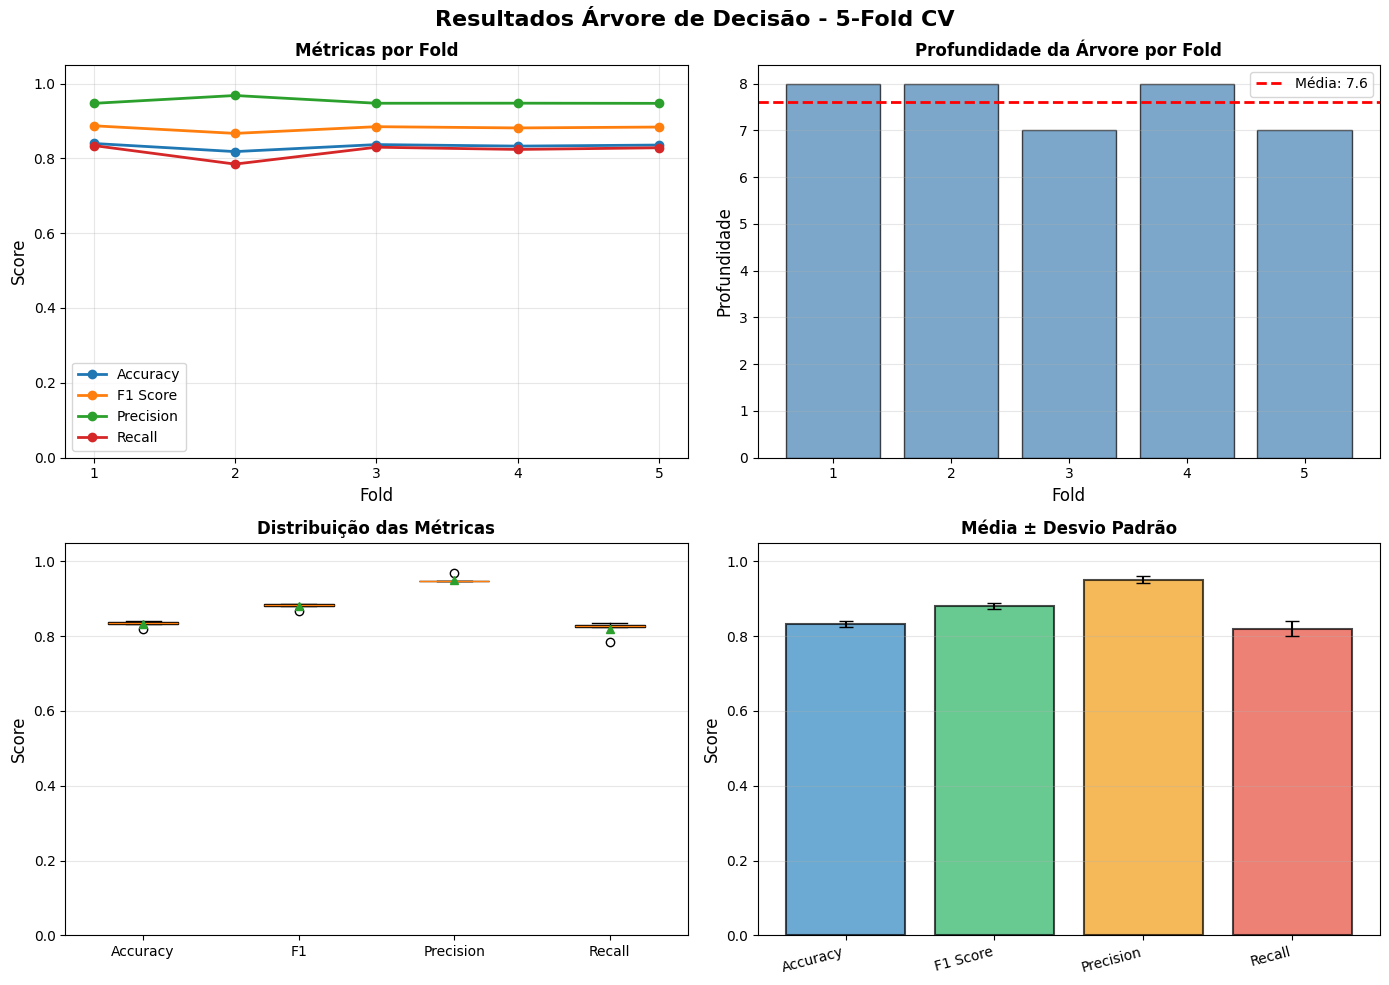

In [35]:
# ============================================================================
# CÉLULA 12: VISUALIZAÇÕES - MÉTRICAS
# ============================================================================

print("\n" + "=" * 70)
print(" VISUALIZAÇÕES")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Resultados Árvore de Decisão - 5-Fold CV', fontsize=16, fontweight='bold')

# 1. Métricas por fold (linhas)
ax1 = axes[0, 0]
for metric in ['accuracy', 'f1_score', 'precision', 'recall']:
    ax1.plot(df_fold_results['fold'], df_fold_results[metric],
             marker='o', label=metric.replace('_', ' ').title(), linewidth=2)
ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Métricas por Fold', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_fold_results['fold'])

# 2. Profundidade da árvore por fold
ax2 = axes[0, 1]
ax2.bar(df_fold_results['fold'], df_fold_results['tree_depth'],
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axhline(y=df_fold_results['tree_depth'].mean(), color='red', linestyle='--',
            label=f'Média: {df_fold_results["tree_depth"].mean():.1f}', linewidth=2)
ax2.set_xlabel('Fold', fontsize=12)
ax2.set_ylabel('Profundidade', fontsize=12)
ax2.set_title('Profundidade da Árvore por Fold', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(df_fold_results['fold'])

# 3. Boxplot das métricas
ax3 = axes[1, 0]
data_boxplot = [df_fold_results['accuracy'], df_fold_results['f1_score'],
                df_fold_results['precision'], df_fold_results['recall']]
bp = ax3.boxplot(data_boxplot, labels=['Accuracy', 'F1', 'Precision', 'Recall'],
                 patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']):
    patch.set_facecolor(color)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Distribuição das Métricas', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Barras com média ± desvio padrão
ax4 = axes[1, 1]
x_pos = np.arange(len(metrics))
means = [df_fold_results[m].mean() for m in metrics]
stds = [df_fold_results[m].std() for m in metrics]
colors = ['#2E86C1', '#28B463', '#F39C12', '#E74C3C']
bars = ax4.bar(x_pos, means, yerr=stds, capsize=5, color=colors,
               alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Média ± Desvio Padrão', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([m.replace('_', ' ').title() for m in metrics], rotation=15, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

for ax in [ax1, ax3, ax4]:
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('arvore_decisao_metricas.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico salvo: arvore_decisao_metricas.png")
plt.show()


Gerando visualização de importância das features...

📊 Análise de importância acumulada:
   - 4 features explicam 80% da importância
   - 5 features explicam 90% da importância

✅ Gráfico salvo: arvore_decisao_feature_importance.png


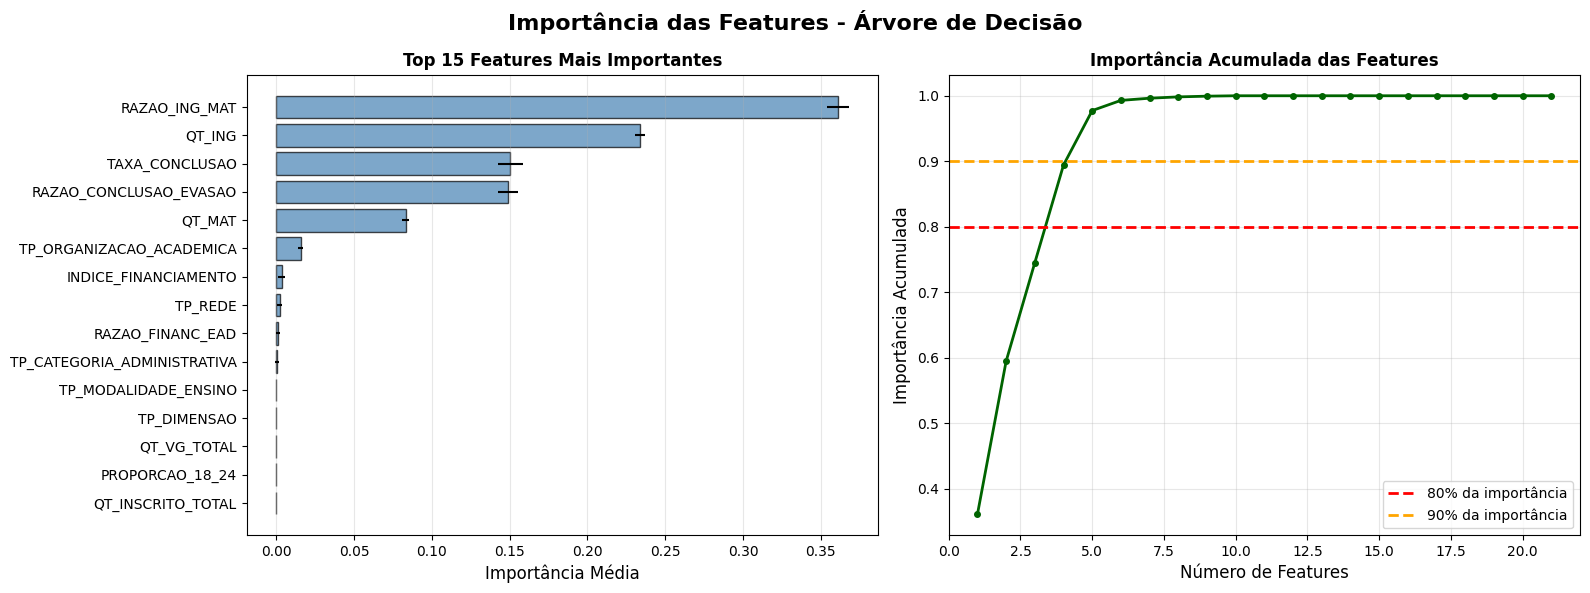

In [36]:
# ============================================================================
# CÉLULA 13: VISUALIZAÇÃO - IMPORTÂNCIA DAS FEATURES
# ============================================================================

print("\nGerando visualização de importância das features...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importância das Features - Árvore de Decisão', fontsize=16, fontweight='bold')

# Top 15 features mais importantes
ax1 = axes[0]
top_features = importance_df.head(15)
y_pos = np.arange(len(top_features))
ax1.barh(y_pos, top_features['importance_mean'],
         xerr=top_features['importance_std'],
         color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_features['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importância Média', fontsize=12)
ax1.set_title('Top 15 Features Mais Importantes', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Distribuição acumulada da importância
ax2 = axes[1]
cumsum_importance = np.cumsum(importance_df['importance_mean'].values)
ax2.plot(range(1, len(cumsum_importance) + 1), cumsum_importance,
         marker='o', linewidth=2, markersize=4, color='darkgreen')
ax2.axhline(y=0.8, color='red', linestyle='--',
            label='80% da importância', linewidth=2)
ax2.axhline(y=0.9, color='orange', linestyle='--',
            label='90% da importância', linewidth=2)
ax2.set_xlabel('Número de Features', fontsize=12)
ax2.set_ylabel('Importância Acumulada', fontsize=12)
ax2.set_title('Importância Acumulada das Features', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Encontrar número de features para 80% e 90%
n_features_80 = np.argmax(cumsum_importance >= 0.8) + 1
n_features_90 = np.argmax(cumsum_importance >= 0.9) + 1
print(f"\n📊 Análise de importância acumulada:")
print(f"   - {n_features_80} features explicam 80% da importância")
print(f"   - {n_features_90} features explicam 90% da importância")

plt.tight_layout()
plt.savefig('arvore_decisao_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico salvo: arvore_decisao_feature_importance.png")
plt.show()


 TREINAMENTO DO MODELO FINAL E VISUALIZAÇÃO DA ÁRVORE

Treinando modelo final com todos os dados...
✅ Modelo final treinado!
   - Profundidade: 5
   - Número de folhas: 12
   - Número de nós: 23

Gerando visualização da árvore (limitada a profundidade 4)...
✅ Visualização salva: arvore_decisao_visualizacao.png


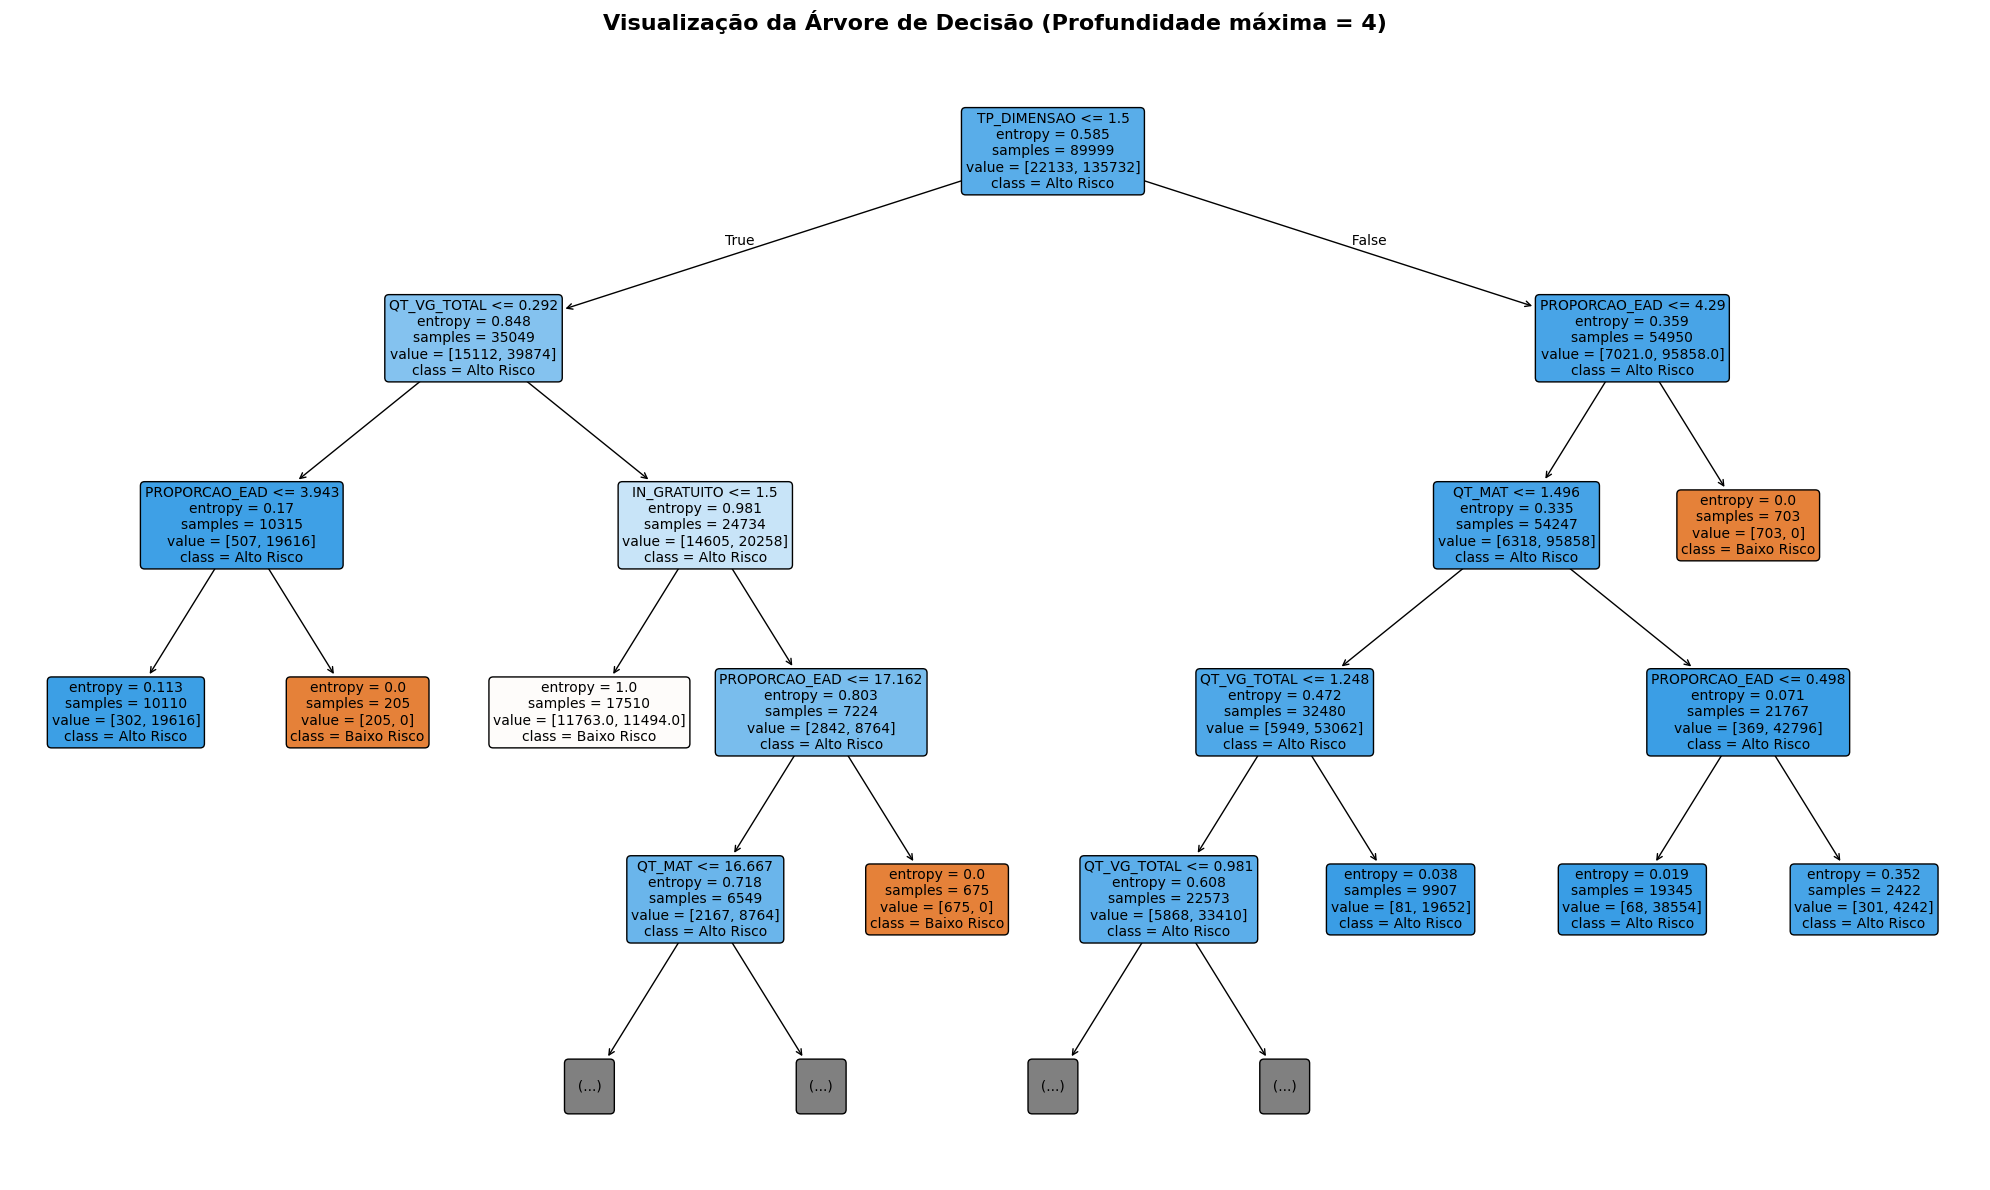


⚠️ NOTA: A árvore completa pode ter profundidade maior.
   A visualização foi limitada a profundidade 4 para melhor legibilidade.


In [37]:
# ============================================================================
# CÉLULA 14: TREINAR MODELO FINAL E VISUALIZAR ÁRVORE
# ============================================================================

print("\n" + "=" * 70)
print(" TREINAMENTO DO MODELO FINAL E VISUALIZAÇÃO DA ÁRVORE")
print("=" * 70)

# Treinar modelo final com todos os dados e melhores hiperparâmetros
print("\nTreinando modelo final com todos os dados...")
final_model = DecisionTreeClassifier(**best_params, random_state=42)
final_model.fit(X_processed, y_processed)

print(f"✅ Modelo final treinado!")
print(f"   - Profundidade: {final_model.get_depth()}")
print(f"   - Número de folhas: {final_model.get_n_leaves()}")
print(f"   - Número de nós: {final_model.tree_.node_count}")

# Visualizar a árvore (limitada para melhor visualização)
print("\nGerando visualização da árvore (limitada a profundidade 4)...")
plt.figure(figsize=(20, 12))
plot_tree(
    final_model,
    feature_names=feature_names,
    class_names=['Baixo Risco', 'Alto Risco'],
    filled=True,
    rounded=True,
    max_depth=4,  # Limitar profundidade para visualização
    fontsize=10
)
plt.title('Visualização da Árvore de Decisão (Profundidade máxima = 4)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('arvore_decisao_visualizacao.png', dpi=300, bbox_inches='tight')
print("✅ Visualização salva: arvore_decisao_visualizacao.png")
plt.show()

print("\n⚠️ NOTA: A árvore completa pode ter profundidade maior.")
print("   A visualização foi limitada a profundidade 4 para melhor legibilidade.")

## 📊 Interpretação dos Resultados

### Vantagens da Árvore de Decisão
- **Interpretabilidade**: Fácil de entender e visualizar
- **Não requer normalização**: Funciona bem com diferentes escalas
- **Lida com não-linearidades**: Captura relações complexas
- **Feature Importance**: Fornece importância das features automaticamente
- **Multiclasse nativo**: Não precisa de estratégias especiais

### Desvantagens
- **Overfitting**: Tendência a memorizar os dados de treino
- **Instabilidade**: Pequenas mudanças nos dados podem mudar a árvore
- **Viés para features com mais valores**: Pode favorecer certas features

### Hiperparâmetros Importantes
- **max_depth**: Controla profundidade máxima (previne overfitting)
- **min_samples_split**: Mínimo de amostras para dividir um nó
- **min_samples_leaf**: Mínimo de amostras em uma folha
- **criterion**: 'gini' ou 'entropy' (medida de impureza)
- **class_weight**: 'balanced' compensa classes desbalanceadas

